<table>
        <td>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="400"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue">  Conceptos de Estadística  </p>    </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Diplomado Ciencia de Datos</p></tp>
            <tp><p style="font-size:115%;text-align:center">Curso 2026-2</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

In [ ]:
%%html
<center><marquee style='width: 60%; color: purple'><b>✌ ¡Hola a todos y a todas! Un saludo... Bienvenidos a la clase de Elementos de Estadística✌ </b></marquee><center>

In [ ]:
# librerías de datos y cálculo
import pandas as pd
import numpy  as np

# librerías para gráficas
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

In [ ]:
# cargamos los datos apartamentos
aptos = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/master/apartamentos.csv")
aptos.head()

,Unnamed: 0,precio,mt2,ubicacion,estrato,alcobas,banos,balcon,parqueadero,administracion,avaluo,terminado
0,1,79.0,43.16,norte,3,3,1,si,si,0.050,14.923002,no
1,2,93.0,56.92,norte,2,2,1,si,si,0.069,27.000000,si
2,3,100.0,66.40,norte,3,2,2,no,no,0.000,15.738427,no
3,4,123.0,61.85,norte,2,3,2,si,si,0.130,27.000000,no
4,5,135.0,89.80,norte,4,3,2,si,no,0.000,39.567000,si


In [ ]:
# eliminar la primera columna "Unnamed: 0" de aptos
aptos.drop(columns="Unnamed: 0", axis = 1, inplace=True)


In [ ]:
aptos.head()

,precio,mt2,ubicacion,estrato,alcobas,banos,balcon,parqueadero,administracion,avaluo,terminado
0,79.0,43.16,norte,3,3,1,si,si,0.050,14.923002,no
1,93.0,56.92,norte,2,2,1,si,si,0.069,27.000000,si
2,100.0,66.40,norte,3,2,2,no,no,0.000,15.738427,no
3,123.0,61.85,norte,2,3,2,si,si,0.130,27.000000,no
4,135.0,89.80,norte,4,3,2,si,no,0.000,39.567000,si


# <FONT SIZE=5 COLOR="purple"> 1. Análisis Exploratorio Unidimensional </FONT>

A continuación revisaremos algunas estadísticas básicas

- Media
- Mediana
- Moda
- Percentiles-Cuartiles
- Desviación Standard y Varianza

1. Media o promedio: **.mean()**

**Para la población**

$$\mu = \dfrac{1}{N}\sum \limits_{i=1}^N x_i$$

N es el tamaño de la población.

**Para la muestra**

$$\overline{x} = \dfrac{1}{n}\sum \limits_{i=1}^n x_i$$

para $n$ tamaño de una muestra.

Algunos puntos a tener en cuenta sobre la media

- Es el "equilibrio" de los datos.
- Se usa para variables cuantitativas.
- Siempre está entre el mínimo y máximo de los datos.
- Es sensible a datos atípicos. Por está razón se debe tener cuidado con su interpretación.

En python se calcula como

$$datos[``variable"].mean()$$

In [ ]:
aptos.precio.mean()

In [ ]:
aptos.ubicacion.unique()

In [ ]:
# calcular la media de precio por ubicacion de aptos
aptos.groupby("ubicacion").precio.mean()

In [ ]:
aptos.mt2.mean()

2. Mediana: **.median()**

- Es el valor que divide los datos en dos partes iguales (50%-50%)
- Aplica para variables cuantitativas
- Puede o no estar en el conjunto de datos. Depende si se tiene un número par o impar de elementos.
- No se ve afectada por la existencia de datos atípicos. Por está razón en ocaciones se usa para imputación.

In [ ]:
aptos.precio.median()

In [ ]:
aptos.mt2.median()

3. Moda: **.mode()**

- Es el valor que más se repite. Es decir el que tiene mayor frecuencia
- Aplica para variables cualitativas y cuantitativas
- UN conjunto puede no tener o tener múltiples modas.

In [ ]:
aptos.ubicacion.mode()

In [ ]:
aptos.ubicacion.value_counts()

In [ ]:
aptos.precio.mode()

In [ ]:
np.array(aptos.precio)

In [ ]:
aptos.precio.value_counts()

In [ ]:
# filtro precio = 220
aptos[aptos.precio == 220]

In [ ]:
aptos["mt2"].mode()

In [ ]:
sum(aptos["mt2"] == 60)

In [ ]:
aptos[aptos["mt2"] == 60]

4. Máximo y mínimo del conjunto: **.max** y **.min**

In [ ]:
# mayor valor de los datos / variables numéricas
aptos.precio.max()

In [ ]:
# menos valor de los datos
aptos.precio.min()

In [ ]:
aptos.precio.describe()

In [ ]:
# Rango en estadística es diferencia entre el máximo y el mínimo.
aptos.precio.max() - aptos.precio.min()

In [ ]:
# función para el rango
def rango(datos,variable):
    return datos[variable].max() - datos[variable].min()

In [ ]:
# modificar la función para que: cuando el usuario ingrese una variable categórica (object) la función indique, "la variable ... es categórica y no se puede calcular el rango"
rango(aptos, "ubicacion") # esto da error

In [ ]:
# ejercicio : modificar la función para que : cuando un usuario ingrese
# una variable tipo object , no de error, sino que indique que no se puede calcular (la variables es categórica)
rango(aptos, "ubicacion")

5. Cuartiles: $Q_1$, $Q_2$ y $Q_3$

- Se calculan para variables cuantitativas
- $Q_1$: el valor que acumula el 25% de los datos
- $Q_2$: es el valor que acumula el 50% de los datos. En ese orden de ideas es la mediana.
- $Q_3$ es el valor que acumula el 75% de los datos.
- Para calcula en Python estos valores y en general los cuantiles usamos la librería *numpy* y la instrucción:

$$ perc\_{n} = np.percentile(variable, n) $$

Veamos algunos ejemplos con la variable *precio* de *aptos*.

In [ ]:
print(np.percentile(aptos.precio,25))  # Q1
print(np.percentile(aptos.precio,50))  # Q2 mediana
print(np.percentile(aptos.precio,75))  # Q3
print(np.percentile(aptos.precio,80))
print(np.percentile(aptos.precio,95))
print(np.percentile(aptos.precio,5))

In [ ]:
aptos.precio.describe()

6. Rango intercuartílico

El rango intercuartílico (RIC), también llamado IQR (Interquartile Range), es una medida de dispersión que indica qué tan separados están los datos centrales de una distribución.

Se define como

$$RIC=Q_3-Q_1$$
	​
donde

- $Q_1$ es el primer cuartil (el 25% de los datos quedan por debajo de él).

- $Q_3$ es el tercer cuartil (el 75% de los datos quedan por debajo de él)

Por tanto, el rango intercuartílico contiene el 50% central de los datos.

In [ ]:
# vamos a hacer un gráfico de cajas y bigotes
px.box(aptos.precio)

In [ ]:
aptos.precio.describe()

In [ ]:
#calculemos el rango intercuartílico
RIC = np.percentile(aptos.precio,75) - np.percentile(aptos.precio,25)
RIC

In [ ]:
# Filtrar los Outliers o atípicos (precio)
aptos_sin_outliers = aptos[aptos.precio <= 710]

In [ ]:
aptos.info()

In [ ]:
aptos_sin_outliers.info()

In [ ]:
aptos.precio.describe()

In [ ]:
aptos_sin_outliers.precio.describe()

In [ ]:
# boxplot de precio en aptos_sin_outliers.precio
px.box(aptos_sin_outliers.precio)

Podemos hacer una función que haga esto

In [ ]:
def RIC(x):
    return np.nanpercentile(x,75) - np.nanpercentile(x,25)

In [ ]:
RIC(aptos.precio)

In [ ]:
# considerar la variable precio
px.box(aptos.precio)

In [ ]:
aptos[aptos.precio >= 710]

6. Valores atípicos (Outliers)

Los valores atípicos son datos que se encuentran muy alejados de la mayoría de las observaciones. Su detección es importante porque pueden afectar los resultados de un análisis estadístico. Antes de eliminarlos o conservarlos, es necesario investigar su origen y comprender qué información aportan sobre el fenómeno que se está estudiando.

Valores menores a

$$Q_1-1.5RIC$$

o mayores a

$$Q_2+1.5RIC$$

se consideran atípicos


In [ ]:
def detectar_outliers(datos, variable):
    """
    Detecta valores atípicos usando el criterio 1.5*RIC.

    Parámetros:
        x: array, lista o Serie de pandas

    Retorna:
        outliers: valores atípicos
        limite_inferior: límite inferior
        limite_superior: límite superior
    """
    q1 = np.nanpercentile(datos[variable], 25)
    q3 = np.nanpercentile(datos[variable], 75)
    ric = q3 - q1

    limite_inferior = q1 - 1.5 * ric
    limite_superior = q3 + 1.5 * ric

    outliers = datos[(datos[variable] < limite_inferior) | (datos[variable] > limite_superior)]
    posiciones = outliers.index
    print(f"Hay {len(outliers)} valores atípicos en la variable {variable}. \n")
    print("estas son las posiciones \n", posiciones)
    display(outliers.head())
    return limite_inferior, limite_superior


In [ ]:
detectar_outliers(aptos,"precio")

In [ ]:
detectar_outliers(aptos,"mt2")

In [ ]:
# medio total de mt2
aptos.mt2.mean()

In [ ]:
# media de mt2 pero sin atípicos
aptos[aptos.mt2 <= 247.875].mt2.mean()

In [ ]:
px.box(aptos.mt2)

In [ ]:
px.box(aptos[aptos.mt2 <= 247.875].mt2)

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=2)

fig.add_trace(
    go.Box(y=aptos[aptos.mt2 <= 247.875].mt2),
    row=1, col=1
)

fig.add_trace(
    go.Box(y=aptos.mt2),
    row=1, col=2
)

fig.show()

In [ ]:
aptos.mt2.median()

In [ ]:
# mediana de mt2 pero sin atípicos
aptos[aptos.mt2 <= 247.875].mt2.median()

También podemos hacer el histograma (para variables continuas)

In [ ]:
aptos.precio.describe()

In [ ]:
px.box( x = aptos.mt2)

In [ ]:
# histrograma
px.histogram(aptos.mt2)

In [ ]:
# histograma de la variable avaluo
px.histogram(aptos,
             x = "avaluo",
             title = "Histograma de la variable avaluo")

In [ ]:
px.box(x = aptos.precio)

El histograma se usa para variables cuantitativas (continuas). Frecuencia por intervalo.

In [ ]:
# histograma de la variable precio
px.histogram(
    aptos,
    x="precio",
    title="Histograma de la variable precio",
    color_discrete_sequence=["green"]
)

6. Desviación Estándar y Varianza

Además de conocer el valor promedio de un conjunto de datos, es importante medir qué tan dispersos o concentrados se encuentran alrededor de ese promedio. Para ello se utilizan medidas de variabilidad o dispersión, entre las que destacan la varianza y la desviación estándar. Estas medidas permiten cuantificar el grado de heterogeneidad de los datos y ayudan a comprender si las observaciones son similares entre sí o presentan una gran variabilidad.

**Para la población**

La desviación estándar para la población de tamaño $N$ es:

$$\sigma = \left(\dfrac{1}{N}\sum \limits_{i=1}^N(x_i-\mu)^2 \right)^{1/2}$$

y la varianza (es el cuadrado de la desviación estándar)

$$\sigma^2 = \dfrac{1}{N}\sum \limits_{i=1}^N(x_i-\mu)^2 $$

**Para la muestra**

La desviación estándar para la muestra de tamaño $n$ es:

$$s = \left(\dfrac{1}{n-1}\sum \limits_{i=1}^n(x_i-\overline{x})^2 \right)^{1/2}$$

y la varianza

$$s^2 = \dfrac{1}{n-1}\sum \limits_{i=1}^n(x_i-\overline{x})^2 $$


In [ ]:
# cálculo en python desviación estándar
x= aptos.precio

# Desviación estándar muestral
s = x.std()

# Desviación estándar poblacional
sigma = x.std(ddof=0)

print("poblacional", sigma)
print("muestral", s)

In [ ]:
aptos.precio.mean()

In [ ]:
# cálculo en python varianza
x= aptos.precio

# Desviación estándar muestral
s2 = x.var()

# Desviación estándar poblacional
sigma2 = x.var(ddof=0)

print("poblacional", sigma2)
print("muestral", s2)

In [ ]:
print(aptos.precio.mean())
print(aptos.precio.std())

In [ ]:
print(aptos.precio.mean())
print(aptos.precio.var())

In [ ]:
aptos.precio.std()**2

In [ ]:
print(aptos.mt2.mean())
print(aptos.mt2.std())

In [ ]:
aptos.mt2.median()

In [ ]:
px.histogram(aptos,
             x = "mt2",
             title = "Histograma de la variable mt2")

In [ ]:
px.box(x= aptos.mt2)

En general trabajamos con la desviación estándar y varianza de la muestra. Es decir con .std() y .var()

6. Tabla de frecuencias

Una tabla de frecuencias es una herramienta estadística que organiza y resume datos, mostrando cuántas veces aparece cada valor o categoría en un conjunto de datos.

In [ ]:
# tabla de frecuencia de la variable ubicacion
aptos.ubicacion.value_counts()

In [ ]:
# para hacer la gráfica de barras de ubicación
px.bar(aptos.ubicacion.value_counts())

In [ ]:
px.histogram(aptos,
             x = "precio",
             title = "Histograma de la variable precio")

In [ ]:
aptos.ubicacion.value_counts()

,count
ubicacion,
poblado,268
aburra sur,169
laureles,73
occidente,69
belen guayabal,67
centro,38
norte,10


In [ ]:
px.bar(aptos.ubicacion.value_counts())

In [ ]:
px.box(aptos.precio)

In [ ]:
px.histogram(aptos.avaluo)

# <FONT SIZE=5 COLOR="purple"> 2. Análisis Exploratorio Multivariado </FONT>

En esta sesión revisaremos algunos elementos fundamentales de análisis exploratorio multivariado como:

- Tablas de contingencias

- Diagramas de dispersión

Por otro lado, revisaremos los conceptos y aplicación del análisis de componentes principales.


## <FONT SIZE=4 COLOR="green"> 2.1 Tablas de Contingencia </FONT>

- Una tabla de contingencia o tabla de frecuencuas cruzadas es una herramienta que nos permite analizar la relación entre dos o más variables categóricas.

Para trabajar en Python una tabla cruzada

$$pd.crosstab(datos[``variable1"], datos[``variable1"])$$

Vamos a hacer la tabla cruzada de las variables : *ubicacion* y *alcobas*

In [ ]:
# tabla cruzada de ubicación con alcobas
pd.crosstab(aptos.ubicacion, aptos.alcobas)

alcobas,1,2,3,4,5,14
ubicacion,,,,,,
aburra sur,6,37,119,6,1,0
belen guayabal,0,6,49,11,1,0
centro,3,10,20,3,1,1
laureles,0,9,54,10,0,0
norte,0,3,6,1,0,0
occidente,0,17,44,8,0,0
poblado,6,46,181,30,5,0


In [ ]:
# tabla de frecuencias anidada
px.bar(pd.crosstab(aptos.ubicacion, aptos.alcobas))

In [ ]:
# tabla de frecuencias  barmode = "group"
px.bar(pd.crosstab(aptos.ubicacion, aptos.alcobas),  barmode='group' )

In [ ]:
np.where(aptos.precio == 47.0)

(array([10]),)

In [ ]:
aptos[aptos.precio == 47.0]

,precio,mt2,ubicacion,estrato,alcobas,banos,balcon,parqueadero,administracion,avaluo,terminado
10,47.0,43.0,occidente,2,2,1,no,no,0.0,16.486,no


In [ ]:
# cruzar: ubicación balcon y terminado
pd.crosstab([aptos.ubicacion, aptos.balcon], aptos.precio)

precio                 25.0    45.0    47.0    53.0    63.0    67.0    70.0    \
ubicacion      balcon                                                           
aburra sur     no           0       0       0       0       1       0       0   
               si           0       1       0       0       0       0       0   
belen guayabal no           0       0       0       0       0       0       0   
               si           0       0       0       0       0       0       0   
centro         no           0       0       0       0       0       1       2   
               si           0       0       0       0       0       0       0   
laureles       no           0       0       0       0       0       0       0   
               si           1       0       0       0       0       0       0   
norte          no           0       0       0       0       0       0       0   
               si           0       0       0       0       0       0       0   
occidente      no           0       0       1       1       0       0       0   
               si           0       0       0       0       0       0       2   
poblado        no           0       0       0       0       0       0       0   
               si           0       0       0       0       0       0       0   

precio                 72.0    75.0    78.0    ...  995.0   1100.0  1200.0  \
ubicacion      balcon                          ...                           
aburra sur     no           0       0       0  ...       0       0       0   
               si           0       0       0  ...       0       0       0   
belen guayabal no           0       1       0  ...       0       0       0   
               si           0       1       0  ...       0       0       0   
centro         no           0       0       1  ...       0       0       0   
               si           0       0       1  ...       0       0       0   
laureles       no           0       0       0  ...       0       0       0   
               si           0       0       0  ...       0       0       0   
norte          no           0       0       0  ...       0       0       0   
               si           0       0       0  ...       0       0       0   
occidente      no           1       0       0  ...       0       0       0   
               si           0       1       0  ...       0       0       0   
poblado        no           0       0       0  ...       0       0       0   
               si           0       0       0  ...       1       4       3   

precio                 1300.0  1350.0  1400.0  1430.0  1450.0  1490.0  1700.0  
ubicacion      balcon                                                          
aburra sur     no           0       0       0       0       0       0       0  
               si           0       0       0       0       0       0       0  
belen guayabal no           0       0       0       0       0       0       0  
               si           0       0       0       0       0       0       0  
centro         no           0       0       0       0       0       0       0  
               si           0       0       0       0       0       0       0  
laureles       no           0       0       0       0       0       0       0  
               si           0       1       0       0       0       0       0  
norte          no           0       0       0       0       0       0       0  
               si           0       0       0       0       0       0       0  
occidente      no           0       0       0       0       0       0       0  
               si           0       0       0       0       0       0       0  
poblado        no           0       0       0       0       0       0       1  
               si           3       2       1       1       2       1       0  

[14 rows x 189 columns]

## <FONT SIZE=4 COLOR="green"> 2.1 Covarianza y Correlación </FONT>

***La Covarianza***

La covarianza es el valor que refleja en que medida dos variables aleatorias varian de forma conjunta respecto a sus medias.

De acuerdo con lo anterior, la covarianza está dada por la siguiente fórmula

$$Muestra: Cov(X,Y)=S_{xy}=\dfrac{\sum \limits_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{n-1}$$

$$Poblacion:COV(X,Y)=\sigma_{XY}=\dfrac{\sum \limits_{i=1}^N (x_i-\mu_x)(y_i-\mu_y)}{N}$$

donde $\overline{x}$ y $\overline{y}$ son las medias de las variables $X$ y $Y$ respectivamente y $n$ es el total de observaciones.

A continuación listaremos algunas propiedades de la covarianza

- $Cov(X,c)=0$, donde $c$ es una constante.

- $Cov(X,X)=Var(X)$, la covarianza de una variable con si misma es la varianza de la variable.

- $Cov(X,Y)=C(Y,X)$, la varianza es simétrica, es decir, no importa el orden en que se coloquen la variables.

- La covarianza mide la fuerza de la relación lineal entre dos variables.

- Una alta covarianza no implica efecto causal.

**Interpretación de la covarianza**

- $Cov(X,Y)>0$ ; las variables $X$ y $Y$ tienden a moverse en la misma dirección.

- $Cov(X,Y)<0$   las variables $X$ y $Y$ tienden a moverse en direcciones opuestas.

- $Cov(X,Y)=0$: las variables $X$ y $Y$ no estan relacionadas linealmente.

***El coeficiente de correlación***

El coeficiente de correlación se define como

$$muestra: r_{xy}=\dfrac{S_{xy}}{S_xS_y} \qquad \qquad poblacion : \rho_{xy}=\dfrac{\sigma_{xy}}{\sigma_{x}\sigma_{y}}$$

lo que es equivalente a

$$r_{xy}=\dfrac{\sum \limits_{i=1}^n (x_i-\overline{x})(y_i-\overline{y})}{\left (\sum \limits_{i=1}^n (x_i-\overline{x})^2 \right)^{1/2} \left ( \sum \limits_{i=1}^n (y_i-\overline{y})^2 \right)^{1/2}}$$

Veamos la interpretación de los diferentes valores del coeficiente de correlación de Pearson, teniendo en cuenta que:

$$-1 \leq r_{xy} \leq 1 $$

<FONT SIZE=3 COLOR="purple"> ***Punto para caso final: demostrar la desigualdad anterior*** </FONT>


- Si $r_{xy}=1$, hay una relación positiva perfecta, es decir, indica una dependencia total entre las variables de manera directa. Si una de ellas aumenta, la otra también lo hace en proporción constante. Es decir, la relación es lineal.

- Si $0<r_{x,y}<1$, existe una correlación positiva.

- Si $r_{x,y}=0$, no existe relación lineal. Pero pueden haber otro tipo de relaciones.

- Si $-1<r_{x,y}<0$, existe una correlación negativa.

- Si $r_{x,y}=-1$, existe una correlación negativa perfecta, es decir, indica una dependencia total de manera inversa. Si una variable disminuye la otra aumenta en proporción constante.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/2af571535cf542cb5e53009d4c148d703ad28a0b/Regresi%C3%B3n/coef_correlacion.png?raw=true" alt="centered image" width="550" height="550"></center>
<br>

Algunas propiedades para tener en cuenta del coeficiente de correlación:

- No depende de las unidades de las variables.

- El coeficiente de Pearson es acotado


In [ ]:
aptos.head()

,precio,mt2,ubicacion,estrato,alcobas,banos,balcon,parqueadero,administracion,avaluo,terminado
0,79.0,43.16,norte,3,3,1,si,si,0.050,14.923002,no
1,93.0,56.92,norte,2,2,1,si,si,0.069,27.000000,si
2,100.0,66.40,norte,3,2,2,no,no,0.000,15.738427,no
3,123.0,61.85,norte,2,3,2,si,si,0.130,27.000000,no
4,135.0,89.80,norte,4,3,2,si,no,0.000,39.567000,si


In [ ]:
# gráfico de dispersión de dos variables precio y mt2
px.scatter(aptos,                # datos
           x = "mt2",            # variable 1
           y = "precio")         # variable 2

In [ ]:
# correlación en numpy
np.corrcoef(aptos["precio"], aptos["mt2"])

array([[1.        , 0.85825847],
       [0.85825847, 1.        ]])

In [ ]:
# para calcular la correlación de dos variables numéricas
np.corrcoef(aptos.precio, aptos.mt2)[0,1]

np.float64(0.8582584650198594)

Ahora haremos el gráfico de dispersión

In [ ]:
aptos.head()

,precio,mt2,ubicacion,estrato,alcobas,banos,balcon,parqueadero,administracion,avaluo,terminado
0,79.0,43.16,norte,3,3,1,si,si,0.050,14.923002,no
1,93.0,56.92,norte,2,2,1,si,si,0.069,27.000000,si
2,100.0,66.40,norte,3,2,2,no,no,0.000,15.738427,no
3,123.0,61.85,norte,2,3,2,si,si,0.130,27.000000,no
4,135.0,89.80,norte,4,3,2,si,no,0.000,39.567000,si


Podemos calcular la correlación de varias variables

In [ ]:
# correlación de varias variables numéricas
aptos[["precio" ,"mt2", "avaluo", "administracion"]].corr()

,precio,mt2,avaluo,administracion
precio,1.000000,0.858258,0.789532,0.752635
mt2,0.858258,1.000000,0.752844,0.774457
avaluo,0.789532,0.752844,1.000000,0.699940
administracion,0.752635,0.774457,0.699940,1.000000


In [ ]:
px.scatter(aptos,
           x = "mt2",
           y = "administracion")

In [ ]:
px.scatter_matrix(aptos[["precio" ,"mt2", "avaluo", "administracion"]],
                  height=1000,
                  width=1000)

También podemos hacer gráficos de dispersión de varias varaibles cruzadas

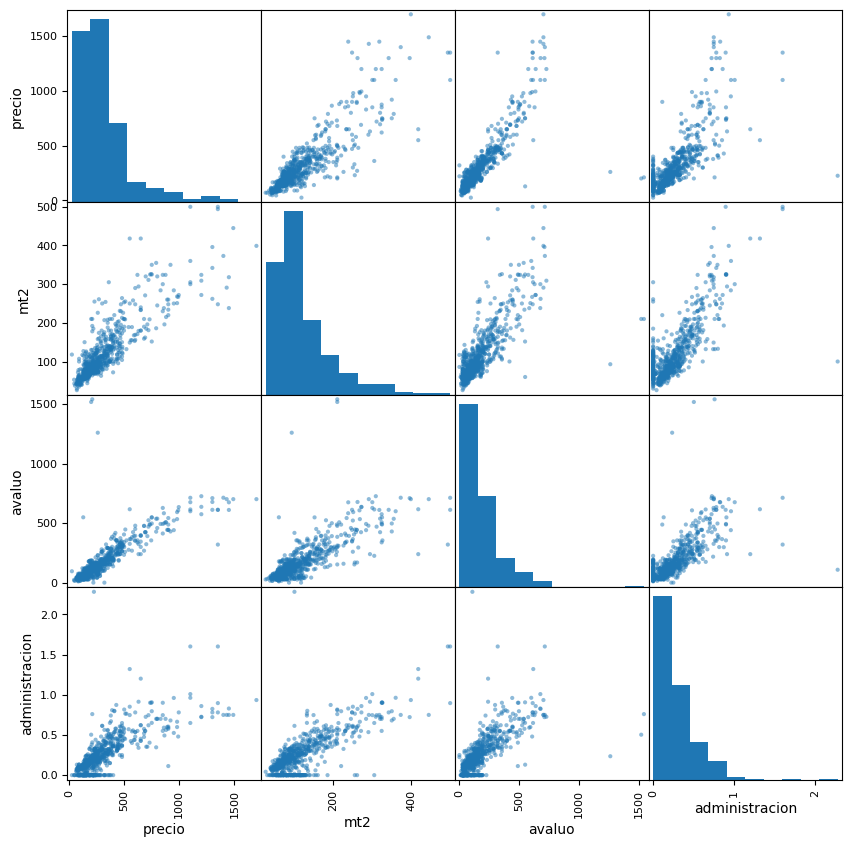

In [ ]:
# gráficos de correlación múltiple entre variables cuantitativas
pd.plotting.scatter_matrix(aptos[["precio" ,"mt2", "avaluo", "administracion"]],
                           figsize=(10, 10))
plt.show()

Veamos algunos ejemplos de cálculo con otro conjunto de datos denominado hospital

In [ ]:
# cargamos el conjunto de datos hospitalización
hospital = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_hospitalizacion_3000.csv")

In [ ]:
hospital.head()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,hospitalizacion
0,40,1,24.23,119.40,55.22,97.00,37.06,95.69,0,5,1
1,60,1,20.37,114.04,85.42,96.29,37.91,107.59,2,3,1
2,26,0,27.10,123.53,70.32,93.35,37.44,71.11,4,4,1
3,25,1,21.09,134.14,69.17,92.01,38.45,115.85,1,3,1
4,44,1,32.99,98.93,68.19,96.44,37.15,94.73,1,7,0


In [ ]:
hospital.corr()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,hospitalizacion
edad,1.000000,-0.004772,-0.012993,0.193672,-0.014075,-0.004877,0.007738,0.187550,0.185306,-0.014260,0.296934
sexo,-0.004772,1.000000,0.019869,-0.001935,0.036783,-0.028599,0.009534,0.000120,-0.021322,-0.048397,0.026008
imc,-0.012993,0.019869,1.000000,-0.002048,-0.011913,0.022632,-0.020447,0.011178,-0.024285,0.023944,0.159649
presion_sistolica,0.193672,-0.001935,-0.002048,1.000000,-0.017253,0.006436,-0.000021,0.038572,0.014449,-0.000413,0.179966
frecuencia_cardiaca,-0.014075,0.036783,-0.011913,-0.017253,1.000000,0.005696,0.005012,-0.015904,0.012059,0.004920,0.113477
saturacion_oxigeno,-0.004877,-0.028599,0.022632,0.006436,0.005696,1.000000,-0.012557,-0.019929,-0.016346,-0.000065,-0.416753
temperatura,0.007738,0.009534,-0.020447,-0.000021,0.005012,-0.012557,1.000000,-0.005825,-0.009607,-0.033116,0.231416
glucosa,0.187550,0.000120,0.011178,0.038572,-0.015904,-0.019929,-0.005825,1.000000,0.015127,0.013646,0.118050
comorbilidades,0.185306,-0.021322,-0.024285,0.014449,0.012059,-0.016346,-0.009607,0.015127,1.000000,-0.009645,0.261550
dias_sintomas,-0.014260,-0.048397,0.023944,-0.000413,0.004920,-0.000065,-0.033116,0.013646,-0.009645,1.000000,0.059516


In [ ]:
px.scatter_matrix(hospital,
                  height=1000,
                  width=1000)

In [ ]:
hospital.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   edad                 3000 non-null   int64  
 1   sexo                 3000 non-null   int64  
 2   imc                  3000 non-null   float64
 3   presion_sistolica    3000 non-null   float64
 4   frecuencia_cardiaca  3000 non-null   float64
 5   saturacion_oxigeno   3000 non-null   float64
 6   temperatura          3000 non-null   float64
 7   glucosa              3000 non-null   float64
 8   comorbilidades       3000 non-null   int64  
 9   dias_sintomas        3000 non-null   int64  
 10  hospitalizacion      3000 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 257.9 KB


Ahora, calculamos la matriz de covarianza

In [ ]:
# Matriz de covarianza variables numéricas
covarianza=hospital.cov(numeric_only= True) ; round(covarianza,2)

Vamos a calcular la matriz de correlación

In [ ]:
# matriz de correlación
corr_hospital = hospital.corr() ; corr_hospital

Mapa de correlaciones

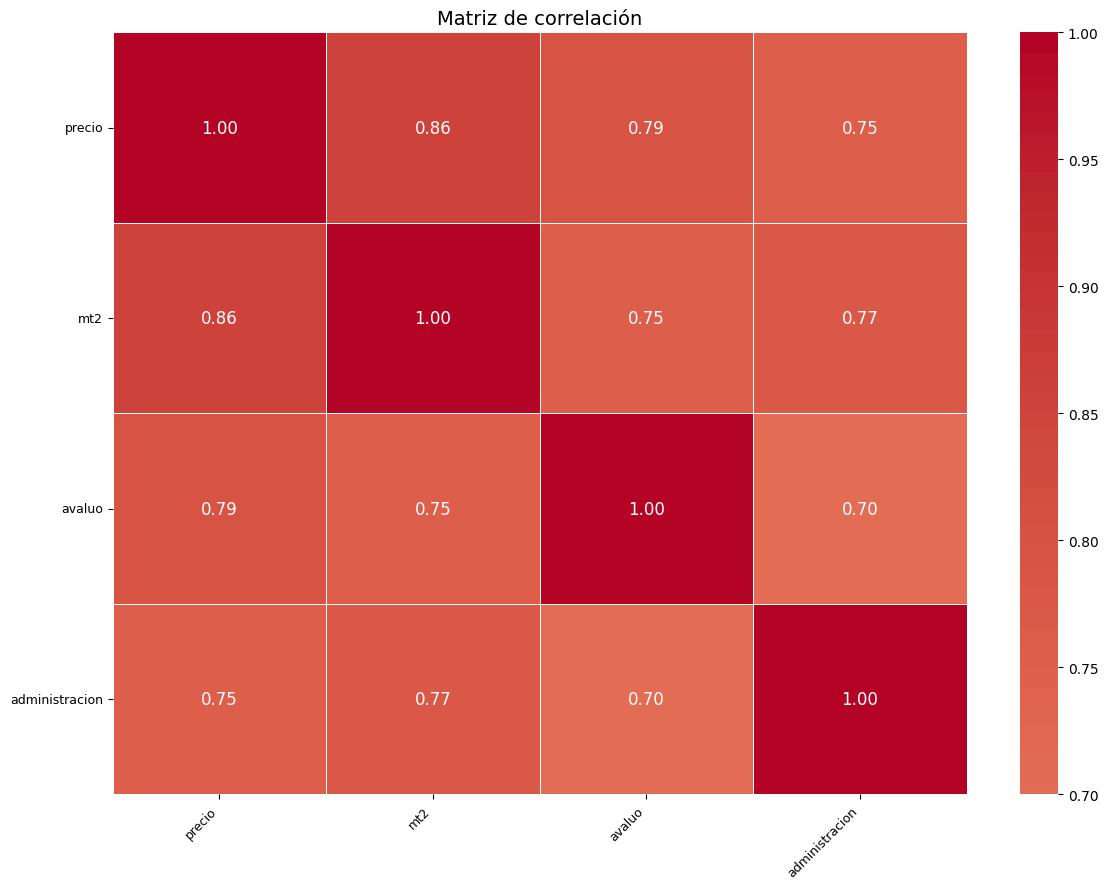

In [ ]:
# diagrama de correlación
plt.figure(figsize=(12, 9))

# Mapa de correlación
sns.heatmap(aptos[["precio" ,"mt2", "avaluo", "administracion"]].corr(),              # matriz de correlaciones
            annot=True,                   # para colocar números adentro (correlaciones)
            fmt=".2f",                    # formato de los números
            cmap="coolwarm",              # colores frio-caliente
            center=0,                     # centro de la escala
            annot_kws={"size": 12},        # tamaño de los números
            linewidths=0.5
)

# Tamaño de etiquetas
plt.xticks(fontsize=9, rotation=45, ha="right")
plt.yticks(fontsize=9, rotation=0)

plt.title("Matriz de correlación", fontsize=14)

plt.tight_layout()
plt.show()

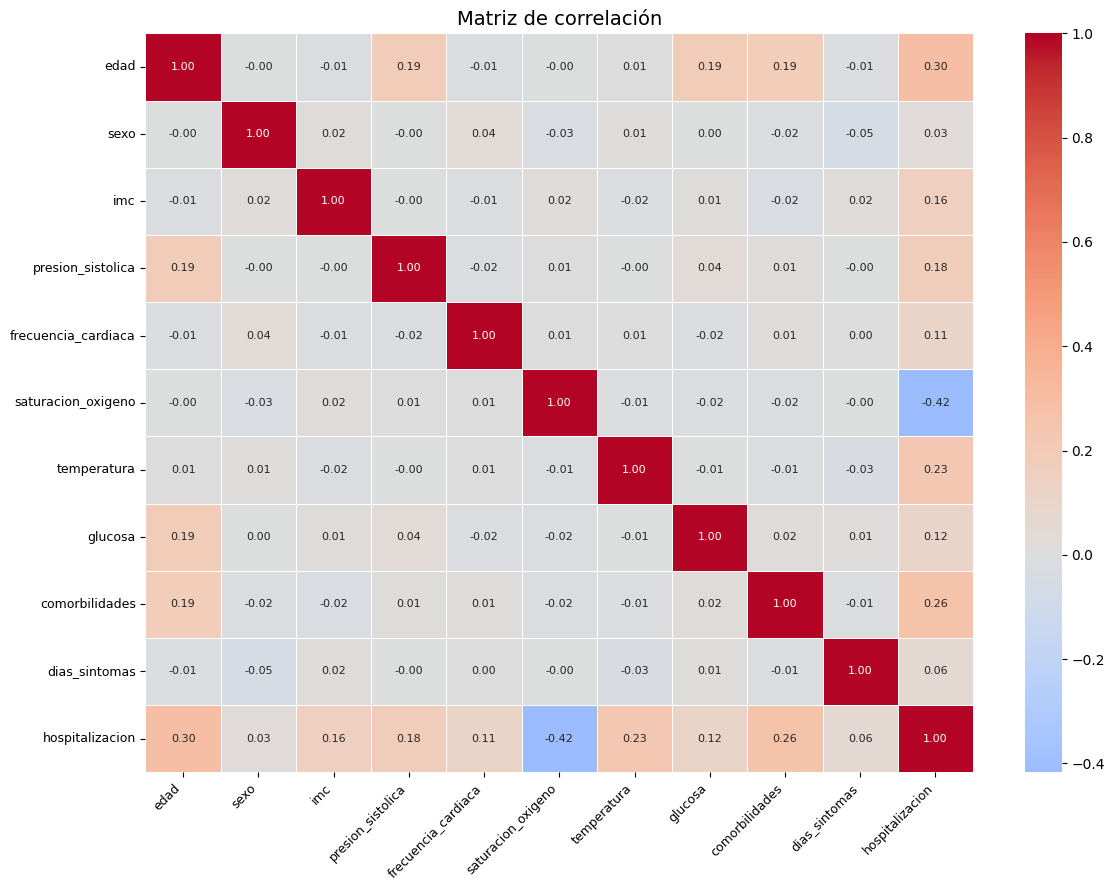

In [ ]:
# diagrama de correlación
plt.figure(figsize=(12, 9))

# Mapa de correlación
sns.heatmap(hospital.corr(),              # matriz de correlaciones
            annot=True,                   # para colocar números adentro (correlaciones)
            fmt=".2f",                    # formato de los números
            cmap="coolwarm",              # colores frio-caliente
            center=0,                     # centro de la escala
            annot_kws={"size": 8},        # tamaño de los números
            linewidths=0.5
)

# Tamaño de etiquetas
plt.xticks(fontsize=9, rotation=45, ha="right")
plt.yticks(fontsize=9, rotation=0)

plt.title("Matriz de correlación", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
px.histogram(aptos.precio)

# <FONT SIZE=5 COLOR="purple"> 3. Distribuciones de Probabilidad - Normal</FONT>

Una distribución de probabilidad es un modelo matemático que describe cómo se distribuyen los valores posibles de una variable aleatoria y qué tan probable es observar cada uno de ellos.

En estadística, las distribuciones permiten responder preguntas como:

¿Cuál es el valor más probable?
¿Qué tan dispersos están los datos?
¿Qué tan raro es observar un valor extremo?

**Distribución normal**

$$f(x)= \dfrac{1}{\sqrt{2\pi}\sigma}{ e^{-\frac{(x-\mu)^2}{2\sigma^2}}}$$



In [ ]:
aptos.head()

In [ ]:
px.histogram(aptos,
             x = "precio",
             title = "Histograma de la variable precio")

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 0
sigma = 1

# Muestra aleatoria
datos = np.random.normal(mu, sigma, 10000)

# Histograma
plt.hist(datos, bins=30, density=True, alpha=0.6)

# Curva teórica
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x, mu, sigma), linewidth=2)

plt.title("Histograma y distribución normal teórica")
plt.xlabel("x")
plt.ylabel("Densidad")
plt.show()

Nos hacemos la siguiente pregunta,

¿Cómo sabemos si unos datos se distribuyen normal?

1. Podemos ver el histograma

2. El gráfico Q-Q (quantile-quantile)

3. Prueba de normalidad *Shapiro-Wilk*

4. Asimetría y curtosis



Veamos un ejemplo

Vamos a estudiar la normalidad de la variable precio, es decir, si los datos provienen de una distribución normal.

**Histograma**

El histograma nos sirve para ver la distribución de los datos, nos da idea si estos se distribuyen normal, pero no da una prueba decisiva. Es mejor usarlo para descartar que no es normal.

In [ ]:
# tomemos los datos precio de apartamentos
px.histogram(aptos,
             x = "precio",
             title = "Histograma de la variable precio")

Observe que de la gráfica, se puede observar que no se comportan como una distribución normal

**Gráfico q-q plot**

El QQ Plot (Quantile-Quantile Plot) es una herramienta gráfica utilizada para evaluar si un conjunto de datos sigue una distribución teórica determinada, generalmente la distribución normal.

El gráfico compara:

- Eje X: cuantiles teóricos de una distribución (por ejemplo, normal).
- Eje Y: cuantiles observados de tus datos.

Cada punto representa la comparación entre un cuantil esperado y uno observado.

Para que los datos se distribuyan normal, la gráfica del qq-plot debe estar alineado con la diagonal.

In [ ]:
# veamos el gráfico q-q
from scipy import stats

stats.probplot(aptos.precio, dist="norm", plot=plt)
plt.show()

**Interpretación**

- Para que los datos tiendan a distribuirse normal el gráfico de los quantiles debería estar cercana a l diagonal.

- En este caso no sucede y por ende no provienen de una distribución normal

**Asimetría**

La **Asimetría** me indica que si la distribución de los datos es simétrica con respecto a la media

  - **Asimetría negativa**: indica datos concentrados a la derecha y colas largas a la izquierda.

  - **Asimetría positiva**: indica datos concentrados a la izquierda y colas largas a la derecha

  - **Asimétria cero**: la distribución tiene a ser simétrica


**Curtosis**

La **curtosis** es una medida estadística que describe qué tan concentrados están los datos alrededor de la media y qué tan pesadas son las colas de una distribución.

  - **Mesocúrtica**: Similar a la normal. Valor cercano a cero

  - **Leptocúrtica**: Distribución con pico alrededor de la media, colas más anchas. valor de curtosis positivo

  - **Platicúrtica**: Distribución achatada alrededor de la media, colas más delgadas. Valor de curtosis negativo

In [ ]:
from scipy.stats import skew, kurtosis

print("Asimetría:", skew(aptos.precio))
print("Curtosis:", kurtosis(aptos.precio))

In [ ]:
from scipy.stats import normaltest

stat, p = normaltest(aptos.precio)

print(f"K² = {stat:.4f}")
print(f"p-value = {p:.4f}")

alpha = 0.05

if p < alpha:
    print("Se rechaza H0: los datos NO son normales")
else:
    print("No se rechaza H0: los datos son compatibles con una distribución normal")

Observe que la distribución de datos es asimétrica positiva : colas largas a derecha y además tiene curtosis positiva (picos alrededor de la media).

En ese sentido, los datos no provienen de una distribución normal.

**Test de Shapiro Wilk**

La prueba de Shapiro-Wilk es una prueba de hipótesis utilizada para determinar si un conjunto de datos sigue una distribución normal. En esta prueba, la hipótesis nula $H_0$ establece que los datos provienen de una población con distribución normal, mientras que la hipótesis alternativa $H_1$ plantea que los datos no siguen una distribución normal. La decisión se toma a partir del valor p obtenido, comparándolo con un nivel de significancia previamente definido.

- **p-value > 0.05**: los datos provienen de una distribución normal

- **p-value <0.05**: los datos no provienen de una distribución normal

Apliquemos el test a nuestros datos



In [ ]:
px.histogram(aptos.precio)

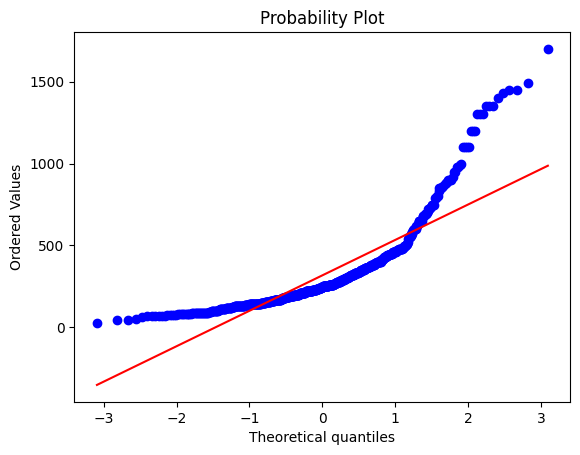

In [ ]:
# veamos el gráfico q-q
from scipy import stats

stats.probplot(aptos.precio, dist="norm", plot=plt)
plt.show()

In [ ]:
# prueba de Shapiro-Wilk
from scipy.stats import shapiro

estadistico, pvalor = shapiro(aptos.precio)

print("Estadístico:", estadistico)
print("p-valor:", pvalor)

Estadístico: 0.760595822082278
p-valor: 1.5504643015609798e-30


En este caso, como $p-value = 1.5 \times e^{-30} << 0.05$, los datos no provienen de una distribución normal.

**Ejemplo 2 Hospital:edad**

Determinar si los datos provienen de una distribución normal.

In [ ]:
hospital.head()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,hospitalizacion
0,40,1,24.23,119.40,55.22,97.00,37.06,95.69,0,5,1
1,60,1,20.37,114.04,85.42,96.29,37.91,107.59,2,3,1
2,26,0,27.10,123.53,70.32,93.35,37.44,71.11,4,4,1
3,25,1,21.09,134.14,69.17,92.01,38.45,115.85,1,3,1
4,44,1,32.99,98.93,68.19,96.44,37.15,94.73,1,7,0


In [ ]:
# histograma
px.histogram(hospital.edad)

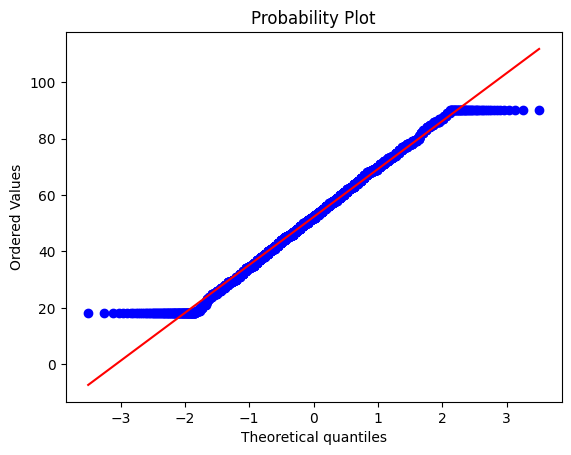

In [ ]:
# qq plot
stats.probplot(hospital.edad, dist="norm", plot=plt)
plt.show()

In [ ]:
# prueba de Shapiro-Wilk (Normalidad)
from scipy.stats import shapiro

estadistico, pvalor = shapiro(hospital.edad)

print("Estadístico:", estadistico)
print("p-valor:", pvalor)

Estadístico: 0.9894353528777928
p-valor: 3.9297193221880295e-14


In [ ]:
from scipy.stats import normaltest

stat, p = normaltest(hospital.edad)

print(f"K² = {stat:.4f}")
print(f"p-value = {p:.4f}")

alpha = 0.05

if p < alpha:
    print("Se rechaza H0: los datos NO son normales")
else:
    print("No se rechaza H0: los datos son compatibles con una distribución normal")

K² = 65.5673
p-value = 0.0000
Se rechaza H0: los datos NO son normales


In [ ]:
# prueba de Shapiro-Wilk (Normalidad)
from scipy.stats import shapiro

estadistico, pvalor = shapiro(hospital.imc)

print("Estadístico:", estadistico)
print("p-valor:", pvalor)

**Ejemplo hospital : imc normalidad**

In [ ]:
px.histogram(hospital,
             x = "imc",
             title = "Histograma de la variable imc")

In [ ]:
# @title
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import norm

# Histograma normalizado
fig = px.histogram(
    hospital,
    x="imc",
    histnorm="probability density",
    nbins=30,
    title="Histograma de BMI con curva normal"
)

# Parámetros de la muestra
mu = hospital["imc"].mean()
sigma = hospital["imc"].std()

# Curva normal ajustada
x = np.linspace(
    hospital["imc"].min(),
    hospital["imc"].max(),
    500
)

y = norm.pdf(x, mu, sigma)

fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="lines",
        name="Normal ajustada"
    )
)

fig.show()

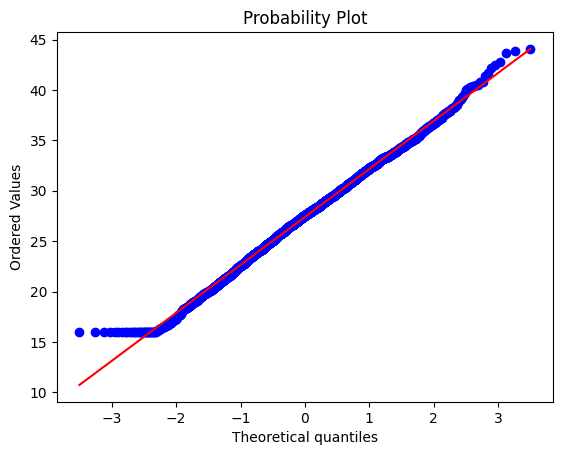

In [ ]:
# veamos el gráfico q-q
from scipy import stats

stats.probplot(hospital.imc,dist="norm",plot=plt)
plt.show()

In [ ]:
# asimetría y curtosis
print("Asimetría:", skew(hospital.imc))
print("Curtosis:", kurtosis(hospital.imc))

In [ ]:
# prueba de Shapiro-Wilk
from scipy.stats import shapiro

estadistico, pvalor = shapiro(hospital.imc)

print("Estadístico:", estadistico)
print("p-valor:", pvalor)

Estadístico: 0.9971172223739803
p-valor: 1.8847458276691895e-05


In [ ]:
from scipy.stats import normaltest

stat, p = normaltest(hospital.imc)

print(f"K² = {stat:.4f}")
print(f"p-value = {p:.4f}")

alpha = 0.05

if p < alpha:
    print("Se rechaza H0: los datos NO son normales")
else:
    print("No se rechaza H0: los datos son compatibles con una distribución normal")

K² = 1.0926
p-value = 0.5791
No se rechaza H0: los datos son compatibles con una distribución normal


In [ ]:
hospital.head()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,hospitalizacion
0,40,1,24.23,119.40,55.22,97.00,37.06,95.69,0,5,1
1,60,1,20.37,114.04,85.42,96.29,37.91,107.59,2,3,1
2,26,0,27.10,123.53,70.32,93.35,37.44,71.11,4,4,1
3,25,1,21.09,134.14,69.17,92.01,38.45,115.85,1,3,1
4,44,1,32.99,98.93,68.19,96.44,37.15,94.73,1,7,0


In [ ]:
px.histogram(hospital.temperatura)

Si bien los datos, tienen un comportamiento parecido a una normal, los criterios determinan que provienen de una población normal.

# <FONT SIZE=5 COLOR="purple"> 4. Pruebas de Hipótesis </FONT>

En muchas situaciones queremos tomar decisiones sobre una población utilizando únicamente una muestra de datos. Las pruebas de hipótesis proporcionan un marco estadístico para determinar si la evidencia observada en una muestra es suficiente para respaldar una afirmación sobre la población.

Por ejemplo:

- ¿La media de ingresos de una ciudad es diferente de $2.000?
- ¿Un nuevo medicamento produce un efecto distinto al tratamiento actual?
- ¿Dos variables están relacionadas?
- ¿Los datos provienen de una distribución normal?

Una prueba de hipótesis no demuestra que una afirmación sea verdadera o falsa; simplemente evalúa si los datos observados son compatibles con una determinada hipótesis.

**Paramétrica**

La prueba de hipótesis sobre un parámetro (media, desviación estandar, proporción) tiene la forma

$$\begin{cases}
H_0:\ \theta = \theta_0,\\[2mm]
H_1:\ \theta \neq \theta_0,
\end{cases}$$

**No paramétrica**

La prueba de hipótesis sobre un parámetro (media, desviación estandar, proporción) tiene la forma

$$\begin{cases}
H_0:\ \text{los datos provienen de una distribución normal}\\[2mm]
H_1:\ \text{los datos no provienen de una distribución normal},
\end{cases}$$

**Rechazar $H_0$**: Existe evidencia de que los datos no provienen de una distribución normal.

**No rechazar $H_0$**: No existe evidencia estadística suficiente para respaldar $H_1$

**Cuidado**: No rechazar una hipótesis no significa probar que es verdadera; significa que la evidencia disponible no es suficiente para descartarla.

**Regla de decisión**

- Si $p \leq 0.05$, se rechaza $H_0$.
  
  Conclusión: existe evidencia de que los datos no siguen una distribución normal.

- Si $p > 0.05$, no se rechaza $H_0$.
  
  Conclusión: no existe evidencia suficiente para afirmar que los datos no siguen una distribución normal.


En ese sentido en **test de Shapiro-Wilk** es una prueba de hipótesis sobre normalidad

$$\begin{cases}
H_0:\ \text{los datos provienen de una distribución normal}\\[2mm]
H_1:\ \text{los datos no provienen de una distribución normal},
\end{cases}$$



Otras pruebas

| Objetivo | Test |
|-----------|--------|
| Verificar normalidad | Shapiro-Wilk |
| Comparar dos grupos independientes | Mann-Whitney U |
| Comparar muestras pareadas (antes/después) | Wilcoxon |
| Comparar tres o más grupos | Kruskal-Wallis |
| Medir asociación entre variables numéricas | Spearman |
| Medir asociación entre variables categóricas | Chi-cuadrado |
| Comparar distribuciones | Kolmogorov-Smirnov |

**Chi-cuadrado de independencia**: ¿Dos variables categóricas son independientes?

$$\begin{cases}
H_0:\ \text{las variables son independientes}\\[2mm]
H_1:\ \text{las variables están asociadas},
\end{cases}$$

- Variables independientes: significa que no existe relación entre ellas. El comportamiento o categoría de una variable no influye ni está asociado con la otra.

- Variables asociadas (o dependientes): significa que existe una relación estadísticamente significativa entre las variables. Conocer la categoría de una variable aporta información sobre la categoría de la otra.



```python
from scipy.stats import chi2_contingency
tabla = pd.crosstab(df.genero, df.compra)
chi2, p, dof, expected = chi2_contingency(tabla)
```

**Mann-Whitney U**: ¿Dos grupos tienen distribuciones diferentes?

```python
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(grupo1, grupo2)
```

**Wilcoxon Signed-Rank**: ¿Existe diferencia antes y después de una intervención?

```python
from scipy.stats import wilcoxon
stat, p = wilcoxon(antes, despues)
```

**Kruskal-Wallis**: ¿Tres o más grupos tienen la misma distribución?

```python
from scipy.stats import kruskal
stat, p = kruskal(g1, g2, g3)
```
**Correlación de Spearman:** ¿Existe una relación monótona entre dos variables?

```python
from scipy.stats import spearmanr
rho, p = spearmanr(x, y)
```





Veamos algunos ejemplos

In [2]:
# librerías de datos y cálculo
import pandas as pd
import numpy  as np

# librerías para gráficas
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

In [3]:
# cargamos el conjunto de datos hospitalización
hospital = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_hospitalizacion_3000.csv")
hospital.head()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,hospitalizacion
0,40,1,24.23,119.40,55.22,97.00,37.06,95.69,0,5,1
1,60,1,20.37,114.04,85.42,96.29,37.91,107.59,2,3,1
2,26,0,27.10,123.53,70.32,93.35,37.44,71.11,4,4,1
3,25,1,21.09,134.14,69.17,92.01,38.45,115.85,1,3,1
4,44,1,32.99,98.93,68.19,96.44,37.15,94.73,1,7,0


In [4]:
# cargar datos diabetes
diabetes = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/diabetes.csv")
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# <FONT SIZE=5 COLOR="purple"> 4.1 Pruebas de Hipótesis: Normalidad </FONT>


**Test de Normalidad**: ¿Dos variables categóricas son independientes?

$$\begin{cases}
H_0:\ \text{los datos se distribuyen normal}\\[2mm]
H_1:\ \text{los datos no se distribuyen normal},
\end{cases}$$

**Ejemplo**

In [12]:
# histograma
px.histogram(hospital.saturacion_oxigeno)

In [13]:
# prueba de normalidad hospital: imc
from scipy.stats import shapiro

estadistico, pvalor = shapiro(hospital.saturacion_oxigeno)

print("Estadístico:", estadistico)
print("p-valor:", pvalor)

Estadístico: 0.993398372801398
p-valor: 1.9335846314718347e-10


Como el $p\_valor = 1.9 \times 10^{-3} < 0.05$ entonces se rechaza la hipotesis $H_0$ de normalidad.

# <FONT SIZE=5 COLOR="purple"> 4.1 Pruebas de Hipótesis: Independencia</FONT>


**Chi-cuadrado de independencia**: ¿Dos variables categóricas son independientes?

$$\begin{cases}
H_0:\ \text{las variables son independientes}\\[2mm]
H_1:\ \text{las variables están asociadas},
\end{cases}$$

- Variables independientes: significa que no existe relación entre ellas. El comportamiento o categoría de una variable no influye ni está asociado con la otra.

- Variables asociadas (o dependientes): significa que existe una relación estadísticamente significativa entre las variables. Conocer la categoría de una variable aporta información sobre la categoría de la otra.


In [14]:
hospital.head()

,edad,sexo,imc,presion_sistolica,frecuencia_cardiaca,saturacion_oxigeno,temperatura,glucosa,comorbilidades,dias_sintomas,hospitalizacion
0,40,1,24.23,119.40,55.22,97.00,37.06,95.69,0,5,1
1,60,1,20.37,114.04,85.42,96.29,37.91,107.59,2,3,1
2,26,0,27.10,123.53,70.32,93.35,37.44,71.11,4,4,1
3,25,1,21.09,134.14,69.17,92.01,38.45,115.85,1,3,1
4,44,1,32.99,98.93,68.19,96.44,37.15,94.73,1,7,0


Revisaremos sexo y hospitalización

In [15]:
# hacemos la tabla cruzada de sexo y hospitalización
tabla = pd.crosstab(hospital.sexo, hospital.hospitalizacion)
tabla

hospitalizacion,0,1
sexo,,
0,768,735
1,726,771


In [16]:
# hacemos la prueba de hipótesis
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla)

print(f"p-value = {p:.4f}")

p-value = 0.1651


Como $$p-value=0.1651 > 0.05$$

no se rechaza la hipótesis nula de independencia $H_0$. Por lo tanto, con un nivel de significancia del $5 \%$, **no hay evidencia estadística suficiente** para afirmar que exista una asociación entre el sexo y la hospitalización.

$α=0.05$ : aceptamos un riesgo del 5 % de concluir que existe una asociación cuando realmente no existe

**Ejemplo 2**

In [17]:
# hacemos la tabla cruzada de sexo y hospitalización
tabla2 = pd.crosstab(hospital.comorbilidades, hospital.hospitalizacion)
tabla2

hospitalizacion,0,1
comorbilidades,,
0,536,283
1,536,492
2,296,374
3,105,244
4,17,85
5,4,25
6,0,3


In [18]:
# hacemos la prueba de hipótesis
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla2)

print(f"p-value = {p:.4f}")

p-value = 0.0000


Como el resultado mostrado es:

$$ p\text{-value}\approx 0.0000 < 0.05 $$

se rechaza $H_0$. Por tanto, **hay evidencia estadística suficiente** para afirmar que el número de comorbilidades está asociado con la hospitalización.

| Comorbilidades | Hospitalizados | Total | Porcentaje hospitalizado |
| -------------: | -------------: | ----: | -----------------------: |
|              0 |            283 |   819 |                   34.6 % |
|              1 |            492 | 1,028 |                   47.9 % |
|              2 |            374 |   670 |                   55.8 % |
|              3 |            244 |   349 |                   69.9 % |
|              4 |             85 |   102 |                   83.3 % |
|              5 |             25 |    29 |                   86.2 % |
|              6 |              3 |     3 |                    100 % |


Con un nivel de significancia del 5 %, se encontró una asociación estadísticamente significativa entre el número de comorbilidades y la hospitalización $(p< 0.05)$. La proporción de pacientes hospitalizados aumenta progresivamente conforme se incrementa el número de comorbilidades. No obstante, las categorías con cinco y seis comorbilidades contienen pocos casos, por lo que se recomienda agrupar las categorías superiores y repetir la prueba.

# <FONT SIZE=5 COLOR="purple"> 5. Estandarizar Datos </FONT>

- La **estandarización** es una técnica de escalamiento que transforma una variable para que tenga media 0 y desviación estándar 1.

Cada observación se expresa en términos de cuántas desviaciones estándar se encuentra por encima o por debajo de la media.

$$\dfrac{x-\mu}{\sigma}$$

- La normalización es una técnica de escalamiento que transforma los datos a un rango fijo, generalmente entre 0 y 1.

$$Min\_Max\_Scaler = \dfrac{x-x_{min}}{x_{max}-x_{min}}$$

In [ ]:
# necesitamos las siguientes librería para escalar
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler1 = StandardScaler()
scaler2 = MinMaxScaler()

In [ ]:
# escalar la variable Edad con StandarScaler
precio_st = scaler1.fit_transform(aptos[["precio"]])

In [ ]:
# escalar la variable Edad con MinMaxScaler
precio_sm = scaler2.fit_transform(aptos[["precio"]])

Veamos el siguiente ejercicio

1. Cargar los datos hepatitis

```python
https://github.com/Fabian830348/Bases_Datos/blob/7dfab7bd5952acddd57d49b3886eccb705d2c019/hepatitis.xlsx
```



In [19]:
# importar hepatitis
hepatitis = pd.read_excel("https://github.com/Fabian830348/Bases_Datos/raw/refs/heads/master/hepatitis.xlsx", na_values=" ")
hepatitis.head()

,Clase,Edad,Sexo,Esteroides,Antivirales,Fatiga,Malestar,Anorexia,Higado Grande,Cirrosis,Bazo palpable,Arañas,Ascites,Varices,Billirubina,Fosfato,SGOT,Albumina,Protina,Histologia
0,Vivo,30,Mujer,No,Sí,Sí,Sí,Sí,No,Sí,Sí,Sí,Sí,Sí,1.0,85,18,4.0,0,No
1,Vivo,50,Hombre,No,Sí,No,Sí,Sí,No,Sí,Sí,Sí,Sí,Sí,0.9,135,42,3.5,0,No
2,Vivo,78,Hombre,Sí,Sí,No,Sí,Sí,Sí,Sí,Sí,Sí,Sí,Sí,0.7,96,32,4.0,0,No
3,Vivo,31,Hombre,NaN,No,Sí,Sí,Sí,Sí,Sí,Sí,Sí,Sí,Sí,0.7,46,52,4.0,80,No
4,Vivo,34,Hombre,Sí,Sí,Sí,Sí,Sí,Sí,Sí,Sí,Sí,Sí,Sí,1.0,0,200,4.0,0,No


In [ ]:
# cabeza de los datos

In [ ]:
# cola de los datos

In [ ]:
# tamaño de los datos

In [ ]:
# información de los datos

In [ ]:
# conteo de los datos faltantes

In [ ]:
# eliminación de los datos faltantes (solo como ejemplo)

In [ ]:
# estadísticas descriptivas de las variables numéricas

In [ ]:
# estadísticas de las variables categóricas


**Análisis de la Variable Edad**

In [ ]:
# información de la variable Edad

In [ ]:
# estadística de la variable

In [ ]:
# histograma de la variable Edad

In [ ]:
# Boxplot de la variable Edad

In [ ]:
# identificar outlier
detectar_outliers(hepatitis, "Edad")

In [ ]:
# Reemplazar el Outlier por el promedio

**Análisis de la Normalidad Edad**

In [ ]:
# histograma

In [ ]:
# q-q plot

In [ ]:
# simetría y curtosis

In [ ]:
# test de normalidad de Shapiro-Wilk

**Análisis de las correlaciones**

In [ ]:
# correlaciones de las variables numéricas

In [ ]:
# mapa de calor de las correlaciones

In [ ]:
# diagramas de dispersión de las variables numéricas

**Tabla de Contingencia de Sexo y Anorexia**

¿Hay asociación entre las variables?

In [ ]:
# tabla de contingencia

In [ ]:
# Aplique el test de chi2_contingency